# Mini-projekt rozdział 4 - Dynamic Programming

Wybrałam pytania A i B:
- A: jak gamma wpływa na v*(start) - porównanie FrozenLake i Gridworld
- B: det vs slippery - co zmienia stochastyczność środowiska

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print("OK")

OK


## Środowiska

Używam dwóch:
- FrozenLake 4x4 (epizodyczne, nagroda +1 za dotarcie do G)
- Gridworld 5x5 z teleportami A i B (continuing, z rozdziału 3)

In [2]:
# FrozenLake - obie wersje
env_det = gym.make("FrozenLake-v1", is_slippery=False)
env_slip = gym.make("FrozenLake-v1", is_slippery=True)

P_fl_det = env_det.unwrapped.P
P_fl_slip = env_slip.unwrapped.P
nS_fl = env_det.observation_space.n
nA_fl = env_det.action_space.n

print(f"FrozenLake: {nS_fl} stanów, {nA_fl} akcji")
print("Stany: 0=S, 5/7/11/12=H (dziury), 15=G (cel)")
print("Akcje: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")

FrozenLake: 16 stanów, 4 akcji
Stany: 0=S, 5/7/11/12=H (dziury), 15=G (cel)
Akcje: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP


In [3]:
# Gridworld 5x5 - ten sam co w rozdziale 3
def build_gridworld_P():
    nrow, ncol = 5, 5
    nS, nA = nrow * ncol, 4
    P = {s: {a: [] for a in range(nA)} for s in range(nS)}

    A, Aprime, rA = (0, 1), (4, 1), 10.0
    B, Bprime, rB = (0, 3), (2, 3), 5.0

    def pos2s(r, c): return r * ncol + c
    moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}

    for s in range(nS):
        r, c = s // ncol, s % ncol
        if (r, c) == A:
            for a in range(nA):
                P[s][a] = [(1.0, pos2s(*Aprime), rA, False)]
            continue
        if (r, c) == B:
            for a in range(nA):
                P[s][a] = [(1.0, pos2s(*Bprime), rB, False)]
            continue
        for a in range(nA):
            dr, dc = moves[a]
            r2, c2 = r + dr, c + dc
            if r2 < 0 or r2 >= nrow or c2 < 0 or c2 >= ncol:
                P[s][a] = [(1.0, s, -1.0, False)]
            else:
                P[s][a] = [(1.0, pos2s(r2, c2), 0.0, False)]

    return P, nS, nA

P_gw, nS_gw, nA_gw = build_gridworld_P()
print(f"Gridworld: {nS_gw} stanów, {nA_gw} akcji")

Gridworld: 25 stanów, 4 akcji


## Algorytmy DP

Implementuję value iteration i policy iteration.
Oba powinny dać to samo v* - sprawdzam to w testach.

In [4]:
def value_iteration(P, nS, nA, gamma=0.9, theta=1e-10):
    """
    Iteruje równanie optymalności Bellmana:
        V(s) = max_a sum p(s'|s,a) * [r + gamma * V(s')]
    
    Zatrzymuje się gdy max zmiana < theta.
    """
    V = np.zeros(nS)

    for _ in range(10000):
        delta = 0.0
        V_new = V.copy()

        for s in range(nS):
            q_values = []
            for a in range(nA):
                if not P[s][a]:
                    continue
                q = sum(p * (r + gamma * (0.0 if done else V[int(s2)]))
                        for p, s2, r, done in P[s][a])
                q_values.append(q)

            if q_values:
                V_new[s] = max(q_values)

            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        if delta < theta:
            break

    # polityka greedy z V*
    pi = np.zeros(nS, dtype=int)
    for s in range(nS):
        best_a, best_q = 0, -np.inf
        for a in range(nA):
            if not P[s][a]:
                continue
            q = sum(p * (r + gamma * (0.0 if done else V[int(s2)]))
                    for p, s2, r, done in P[s][a])
            if q > best_q:
                best_q, best_a = q, a
        pi[s] = best_a

    return pi, V


def policy_evaluation(P, nS, nA, pi, gamma=0.9, theta=1e-10):
    """Liczy V_pi dla zadanej polityki."""
    V = np.zeros(nS)
    while True:
        delta = 0.0
        for s in range(nS):
            a = pi[s]
            if not P[s][a]:
                continue
            v = sum(p * (r + gamma * (0.0 if done else V[int(s2)]))
                    for p, s2, r, done in P[s][a])
            delta = max(delta, abs(v - V[s]))
            V[s] = v
        if delta < theta:
            break
    return V


def policy_iteration(P, nS, nA, gamma=0.9, theta=1e-10):
    """
    Naprzemiennie ewaluuje politykę i ją poprawia,
    aż polityka się nie zmieni.
    """
    pi = np.zeros(nS, dtype=int)

    while True:
        V = policy_evaluation(P, nS, nA, pi, gamma, theta)

        pi_new = np.zeros(nS, dtype=int)
        for s in range(nS):
            best_a, best_q = 0, -np.inf
            for a in range(nA):
                if not P[s][a]:
                    continue
                q = sum(p * (r + gamma * (0.0 if done else V[int(s2)]))
                        for p, s2, r, done in P[s][a])
                if q > best_q:
                    best_q, best_a = q, a
            pi_new[s] = best_a

        if np.array_equal(pi_new, pi):
            break
        pi = pi_new

    return pi, V


# Sprawdzenie czy VI i PI dają to samo
pi_vi, v_vi = value_iteration(P_fl_det, nS_fl, nA_fl, gamma=0.9)
pi_pi, v_pi = policy_iteration(P_fl_det, nS_fl, nA_fl, gamma=0.9)

print("Test (FrozenLake det, gamma=0.9):")
print(f"  v*(0) VI = {v_vi[0]:.4f}")
print(f"  v*(0) PI = {v_pi[0]:.4f}")
print(f"  Różnica = {abs(v_vi[0] - v_pi[0]):.2e}")

Test (FrozenLake det, gamma=0.9):
  v*(0) VI = 0.5905
  v*(0) PI = 0.5905
  Różnica = 0.00e+00


## Pytanie A - wpływ gamma na v*(start)

W FrozenLake nagroda jest na końcu epizodu (+1 za G), więc v*(start) ≈ gamma^L
gdzie L to długość najkrótszej ścieżki.

W Gridworld nagrody zbieramy w nieskończoność, więc wpływ gamma powinien być inny.

In [5]:
gammas = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
start_state = 0

vstarts_fl_det = []
vstarts_fl_slip = []
vstarts_gw = []

for g in gammas:
    _, v = value_iteration(P_fl_det, nS_fl, nA_fl, gamma=g)
    vstarts_fl_det.append(float(v[start_state]))

    _, v = value_iteration(P_fl_slip, nS_fl, nA_fl, gamma=g)
    vstarts_fl_slip.append(float(v[start_state]))

    _, v = value_iteration(P_gw, nS_gw, nA_gw, gamma=g)
    vstarts_gw.append(float(v[start_state]))

print(f"{'gamma':<8} {'FL det':<12} {'FL slip':<12} {'Gridworld':<12}")
print("-" * 44)
for g, v1, v2, v3 in zip(gammas, vstarts_fl_det, vstarts_fl_slip, vstarts_gw):
    print(f"{g:<8.2f} {v1:<12.4f} {v2:<12.4f} {v3:<12.4f}")

gamma    FL det       FL slip      Gridworld   
--------------------------------------------
0.50     0.0312       0.0004       5.1613      
0.70     0.1681       0.0045       8.4142      
0.80     0.3277       0.0154       11.8991     
0.90     0.5905       0.0689       21.9775     
0.95     0.7738       0.1805       41.9947     
0.99     0.9510       0.5420       201.9998    


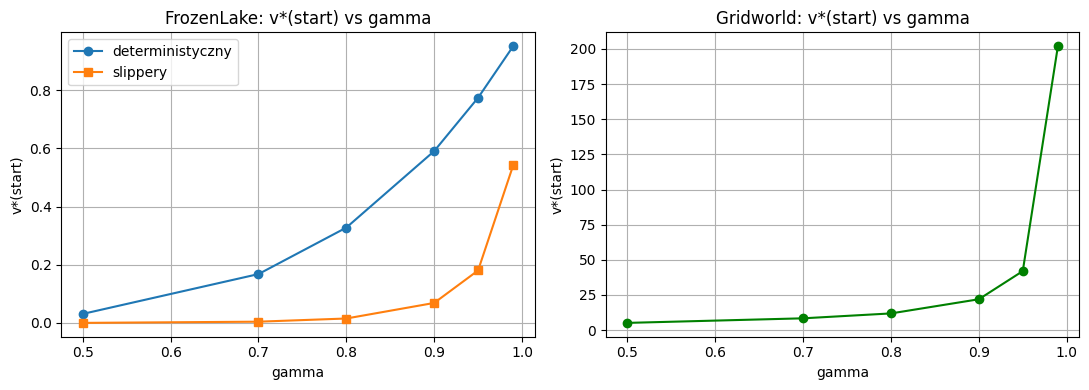

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(gammas, vstarts_fl_det, marker='o', label='deterministyczny')
ax1.plot(gammas, vstarts_fl_slip, marker='s', label='slippery')
ax1.set_xlabel('gamma')
ax1.set_ylabel('v*(start)')
ax1.set_title('FrozenLake: v*(start) vs gamma')
ax1.legend()
ax1.grid(True)

ax2.plot(gammas, vstarts_gw, marker='o', color='green')
ax2.set_xlabel('gamma')
ax2.set_ylabel('v*(start)')
ax2.set_title('Gridworld: v*(start) vs gamma')
ax2.grid(True)

plt.tight_layout()
plt.show()

W FrozenLake det zależność wygląda wykładniczo - to ma sens, bo robot idzie do celu po ~6 krokach,
więc v*(start) ≈ gamma^6. Przy gamma=0.5 to daje ~0.016, a przy gamma=0.99 ~0.94, co zgadza się z tabelą.

W Gridworld wzrost jest znacznie szybszy przy dużych gamma. Przy gamma=0.99 wartości są duże,
bo sumujemy nagrody z nieskończenie wielu kroków i każda nie jest prawie wcale zdyskontowana.
To pokazuje czemu w zadaniach continuing ważne jest żeby gamma < 1 - bez dyskontowania suma by nie zbiegała.

## Pytanie B - det vs slippery

W slippery FrozenLake z p=1/3 robot idzie gdzie chce, a z p=2/3 ląduje prostopadle.
To mocno utrudnia dojście do celu, zwłaszcza że plansza ma dziury.

In [7]:
gamma = 0.9

pi_det, v_det = value_iteration(P_fl_det, nS_fl, nA_fl, gamma=gamma)
pi_slip, v_slip = value_iteration(P_fl_slip, nS_fl, nA_fl, gamma=gamma)

print(f"gamma = {gamma}")
print(f"v*(start) det  = {v_det[0]:.4f}")
print(f"v*(start) slip = {v_slip[0]:.4f}")
print(f"Slippery gorsze o {(v_det[0] - v_slip[0]) / v_det[0] * 100:.0f}%")

# Wypisz polityki
arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
holes = {5, 7, 11, 12}

def print_policy(pi, label):
    print(f"\nPolityka {label}:")
    for r in range(4):
        row = []
        for c in range(4):
            s = r * 4 + c
            if s in holes:
                row.append('H')
            elif s == 15:
                row.append('G')
            else:
                row.append(arrows[pi[s]])
        print('  ' + ' '.join(row))

print_policy(pi_det, 'det')
print_policy(pi_slip, 'slip')

gamma = 0.9
v*(start) det  = 0.5905
v*(start) slip = 0.0689
Slippery gorsze o 88%

Polityka det:
  ↓ → ↓ ←
  ↓ H ↓ H
  → ↓ ↓ H
  H → → G

Polityka slip:
  ← ↑ ← ↑
  ← H ← H
  ↑ ↓ ← H
  H → ↓ G


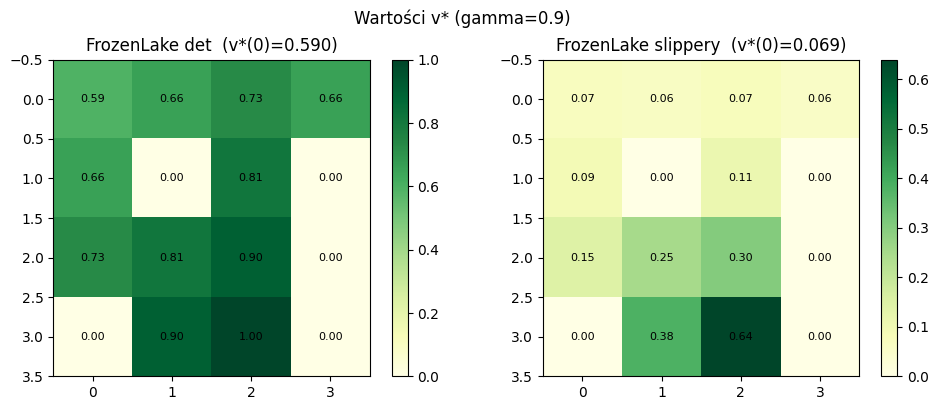

In [8]:
# Porównanie funkcji wartości
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, v, title in zip(axes, [v_det, v_slip], ['det', 'slippery']):
    im = ax.imshow(v.reshape(4, 4), cmap='YlGn')
    ax.set_title(f'FrozenLake {title}  (v*(0)={v[0]:.3f})')
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{v[i*4+j]:.2f}", ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle(f'Wartości v* (gamma={gamma})')
plt.tight_layout()
plt.show()

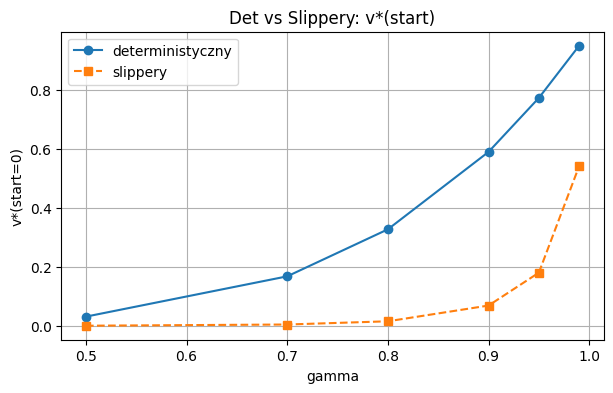

Stosunek slip/det:
  gamma=0.50: 0.012  (slip = 1% wartości det)
  gamma=0.70: 0.027  (slip = 3% wartości det)
  gamma=0.80: 0.047  (slip = 5% wartości det)
  gamma=0.90: 0.117  (slip = 12% wartości det)
  gamma=0.95: 0.233  (slip = 23% wartości det)
  gamma=0.99: 0.570  (slip = 57% wartości det)


In [9]:
# Sweep gamma - det vs slip na jednym wykresie
vs_det, vs_slip = [], []

for g in gammas:
    _, v = value_iteration(P_fl_det, nS_fl, nA_fl, gamma=g)
    vs_det.append(float(v[0]))
    _, v = value_iteration(P_fl_slip, nS_fl, nA_fl, gamma=g)
    vs_slip.append(float(v[0]))

plt.figure(figsize=(7, 4))
plt.plot(gammas, vs_det, marker='o', label='deterministyczny')
plt.plot(gammas, vs_slip, marker='s', linestyle='--', label='slippery')
plt.xlabel('gamma')
plt.ylabel('v*(start=0)')
plt.title('Det vs Slippery: v*(start)')
plt.legend()
plt.grid(True)
plt.show()

print("Stosunek slip/det:")
for g, vd, vs in zip(gammas, vs_det, vs_slip):
    print(f"  gamma={g:.2f}: {vs/vd:.3f}  (slip = {vs/vd*100:.0f}% wartości det)")

Slippery drastycznie obniża v*(start) - przy gamma=0.9 wartość spada z 0.59 do 0.07.
Robot jest ~8x gorszy mimo że stosuje najlepszą możliwą politykę.

Polityki pi* też się różnią. W det robot idzie prosto najkrótszą ścieżką.
W slippery jest bardziej zachowawczy - omija dziury z daleka bo wie że może
niezamierzenie zjechać w bok.

Przy dużym gamma (0.99) różnica procentowa maleje - w det v*(0)=0.95, w slip=0.54.
Stosunek slip/det rośnie z 0.01 przy gamma=0.5 do 0.57 przy gamma=0.99.
To dlatego że przy dużym gamma robot jest w stanie "czekać" i próbować wiele razy -
każda nieudana próba kosztuje stosunkowo mało jeśli przyszłość jest dużo warta.